Installations & Setup

In [4]:
%pip install scipy 


Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr, mannwhitneyu, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
%pip install pingouin
import pingouin as pg

warnings.filterwarnings("ignore")

PALETTE   = "muted"
FIG_DPI   = 150
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.1)
plt.rcParams.update({"figure.dpi": FIG_DPI, "axes.titlesize": 13})

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 204 kB 6.6 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 26.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Load Data

In [3]:
PARQUET = "./outputs/part1/df_engineered.parquet"
CSV_PATH = "/Users/shikh/Downloads/HW Winter 26/ig_datasets/instagram_usage_lifestyle.csv"   # fallback

print(f"\n[0] Loading data ...")
if os.path.exists(PARQUET):
    df = pd.read_parquet(PARQUET)
    print(f"    Loaded from parquet: {df.shape}")
else:
    df = pd.read_csv(CSV_PATH, low_memory=False)
    print(f"    Loaded from CSV: {df.shape}")

# Reconstruct engineered features if missing
if "log_daily_active_minutes_instagram" not in df.columns:
    for col in ["daily_active_minutes_instagram", "followers_count",
                "following_count", "reels_watched_per_day"]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col].clip(lower=0))

if "age_group" not in df.columns:
    df["age_group"] = pd.cut(df["age"], bins=[13, 18, 25, 35, 45, 55, 100],
                             labels=["13-18", "19-25", "26-35", "36-45", "46-55", "55+"])

if "high_stress_binary" not in df.columns:
    stress_75 = df["perceived_stress_score"].quantile(0.75)
    df["high_stress_binary"] = (df["perceived_stress_score"] >= stress_75).astype(int)

# Work sample for heavy computations (500k for speed, all for stats)
SAMPLE_N = 500_000
df_sample = df.sample(min(SAMPLE_N, len(df)), random_state=42).copy()
print(f"    Analysis sample: {len(df_sample):,} rows")



[0] Loading data ...
    Loaded from CSV: (1547896, 58)
    Analysis sample: 500,000 rows


Encode Categorical Variable

In [4]:
# Ordinal encoding for ordered categoricals
income_map = {"Low": 1, "Lower-Middle": 2, "Middle": 3, "Upper-Middle": 4, "High": 5}
edu_map = {"No Formal Education": 1, "High School": 2, "Some College": 3,
           "Bachelor's": 4, "Master's": 5, "PhD": 6, "Other": 3}

for col, mapping in [("income_level", income_map), ("education_level", edu_map)]:
    if col in df_sample.columns:
        df_sample[f"{col}_num"] = df_sample[col].map(mapping).fillna(3).astype(int)

# Binary encoding
if "gender" in df_sample.columns:
    df_sample["female"] = (df_sample["gender"] == "Female").astype(int)
    df_sample["nonbinary"] = (df_sample["gender"] == "Non-binary").astype(int)

if "urban_rural" in df_sample.columns:
    df_sample["urban"] = (df_sample["urban_rural"] == "Urban").astype(int)
    df_sample["suburban"] = (df_sample["urban_rural"] == "Suburban").astype(int)

if "smoking" in df_sample.columns:
    df_sample["smoker"] = (df_sample["smoking"].astype(str).str.lower()
                           .isin(["yes", "1", "true"])).astype(int)

print("    Encoding complete.")


    Encoding complete.


Define Feature Sets for Models

In [5]:
# Core Instagram behavioral predictors (checking availability)
IG_PASSIVE = [c for c in ["reels_watched_per_day", "stories_viewed_per_day",
                           "time_on_feed_per_day", "time_on_explore_per_day",
                           "ads_viewed_per_day"] if c in df_sample.columns]

IG_ACTIVE  = [c for c in ["posts_created_per_week", "comments_written_per_day",
                           "dms_sent_per_week", "likes_given_per_day"] if c in df_sample.columns]

# Build composite indices (standardized means)
sc_fit = StandardScaler()
if len(IG_PASSIVE) >= 2:
    df_sample["passive_index"] = sc_fit.fit_transform(
        df_sample[IG_PASSIVE].fillna(df_sample[IG_PASSIVE].median())
    ).mean(axis=1)
else:
    df_sample["passive_index"] = 0.0

sc_fit2 = StandardScaler()
if len(IG_ACTIVE) >= 2:
    df_sample["active_index"] = sc_fit2.fit_transform(
        df_sample[IG_ACTIVE].fillna(df_sample[IG_ACTIVE].median())
    ).mean(axis=1)
else:
    df_sample["active_index"] = 0.0

# Covariate sets
DEMO_COVARIATES = [c for c in [
    "age", "female", "nonbinary", "urban", "suburban",
    "income_level_num", "education_level_num"
] if c in df_sample.columns]

IG_PREDICTORS = [c for c in [
    "passive_index", "active_index",
    "sessions_per_day", "average_session_length_minutes",
    "notification_response_rate",
] if c in df_sample.columns]

LIFESTYLE_PREDS = [c for c in [
    "exercise_hours_per_week", "sleep_hours_per_night",
    "hobbies_count", "weekly_work_hours",
    "social_events_per_month", "books_read_per_year",
] if c in df_sample.columns]

ALL_PREDICTORS = DEMO_COVARIATES + IG_PREDICTORS + LIFESTYLE_PREDS

print(f"\n    Feature sets:")
print(f"      DEMO_COVARIATES  : {len(DEMO_COVARIATES)} features")
print(f"      IG_PREDICTORS    : {len(IG_PREDICTORS)} features")
print(f"      LIFESTYLE_PREDS  : {len(LIFESTYLE_PREDS)} features")
print(f"      ALL_PREDICTORS   : {len(ALL_PREDICTORS)} features")


    Feature sets:
      DEMO_COVARIATES  : 7 features
      IG_PREDICTORS    : 5 features
      LIFESTYLE_PREDS  : 6 features
      ALL_PREDICTORS   : 18 features


OLS Regression- percieved stress score


      Model M1 (Demographics only): n=500,000, R²=0.0000, adj-R²=-0.0000, F=0.92
      Top standardized betas (|beta*| > 0.05):

      Model M2 (+Instagram): n=500,000, R²=0.7140, adj-R²=0.7140, F=156148.38
      Top standardized betas (|beta*| > 0.05):
        passive_index                             beta*=+0.5908  [+0.5857, +0.5959]
        active_index                              beta*=+0.2404  [+0.2357, +0.2451]
        age                                       beta*=+0.2399  [+0.2384, +0.2415]
        sessions_per_day                          beta*=+0.0668  [+0.0639, +0.0697]

      Model M3 (Full model): n=500,000, R²=0.7140, adj-R²=0.7140, F=104097.65
      Top standardized betas (|beta*| > 0.05):
        passive_index                             beta*=+0.5908  [+0.5857, +0.5959]
        active_index                              beta*=+0.2404  [+0.2357, +0.2451]
        age                                       beta*=+0.2399  [+0.2384, +0.2415]
        sessions_per_day       

Text(0.5, 0.98, 'Figure 15 — Incremental R² across Nested OLS Models')

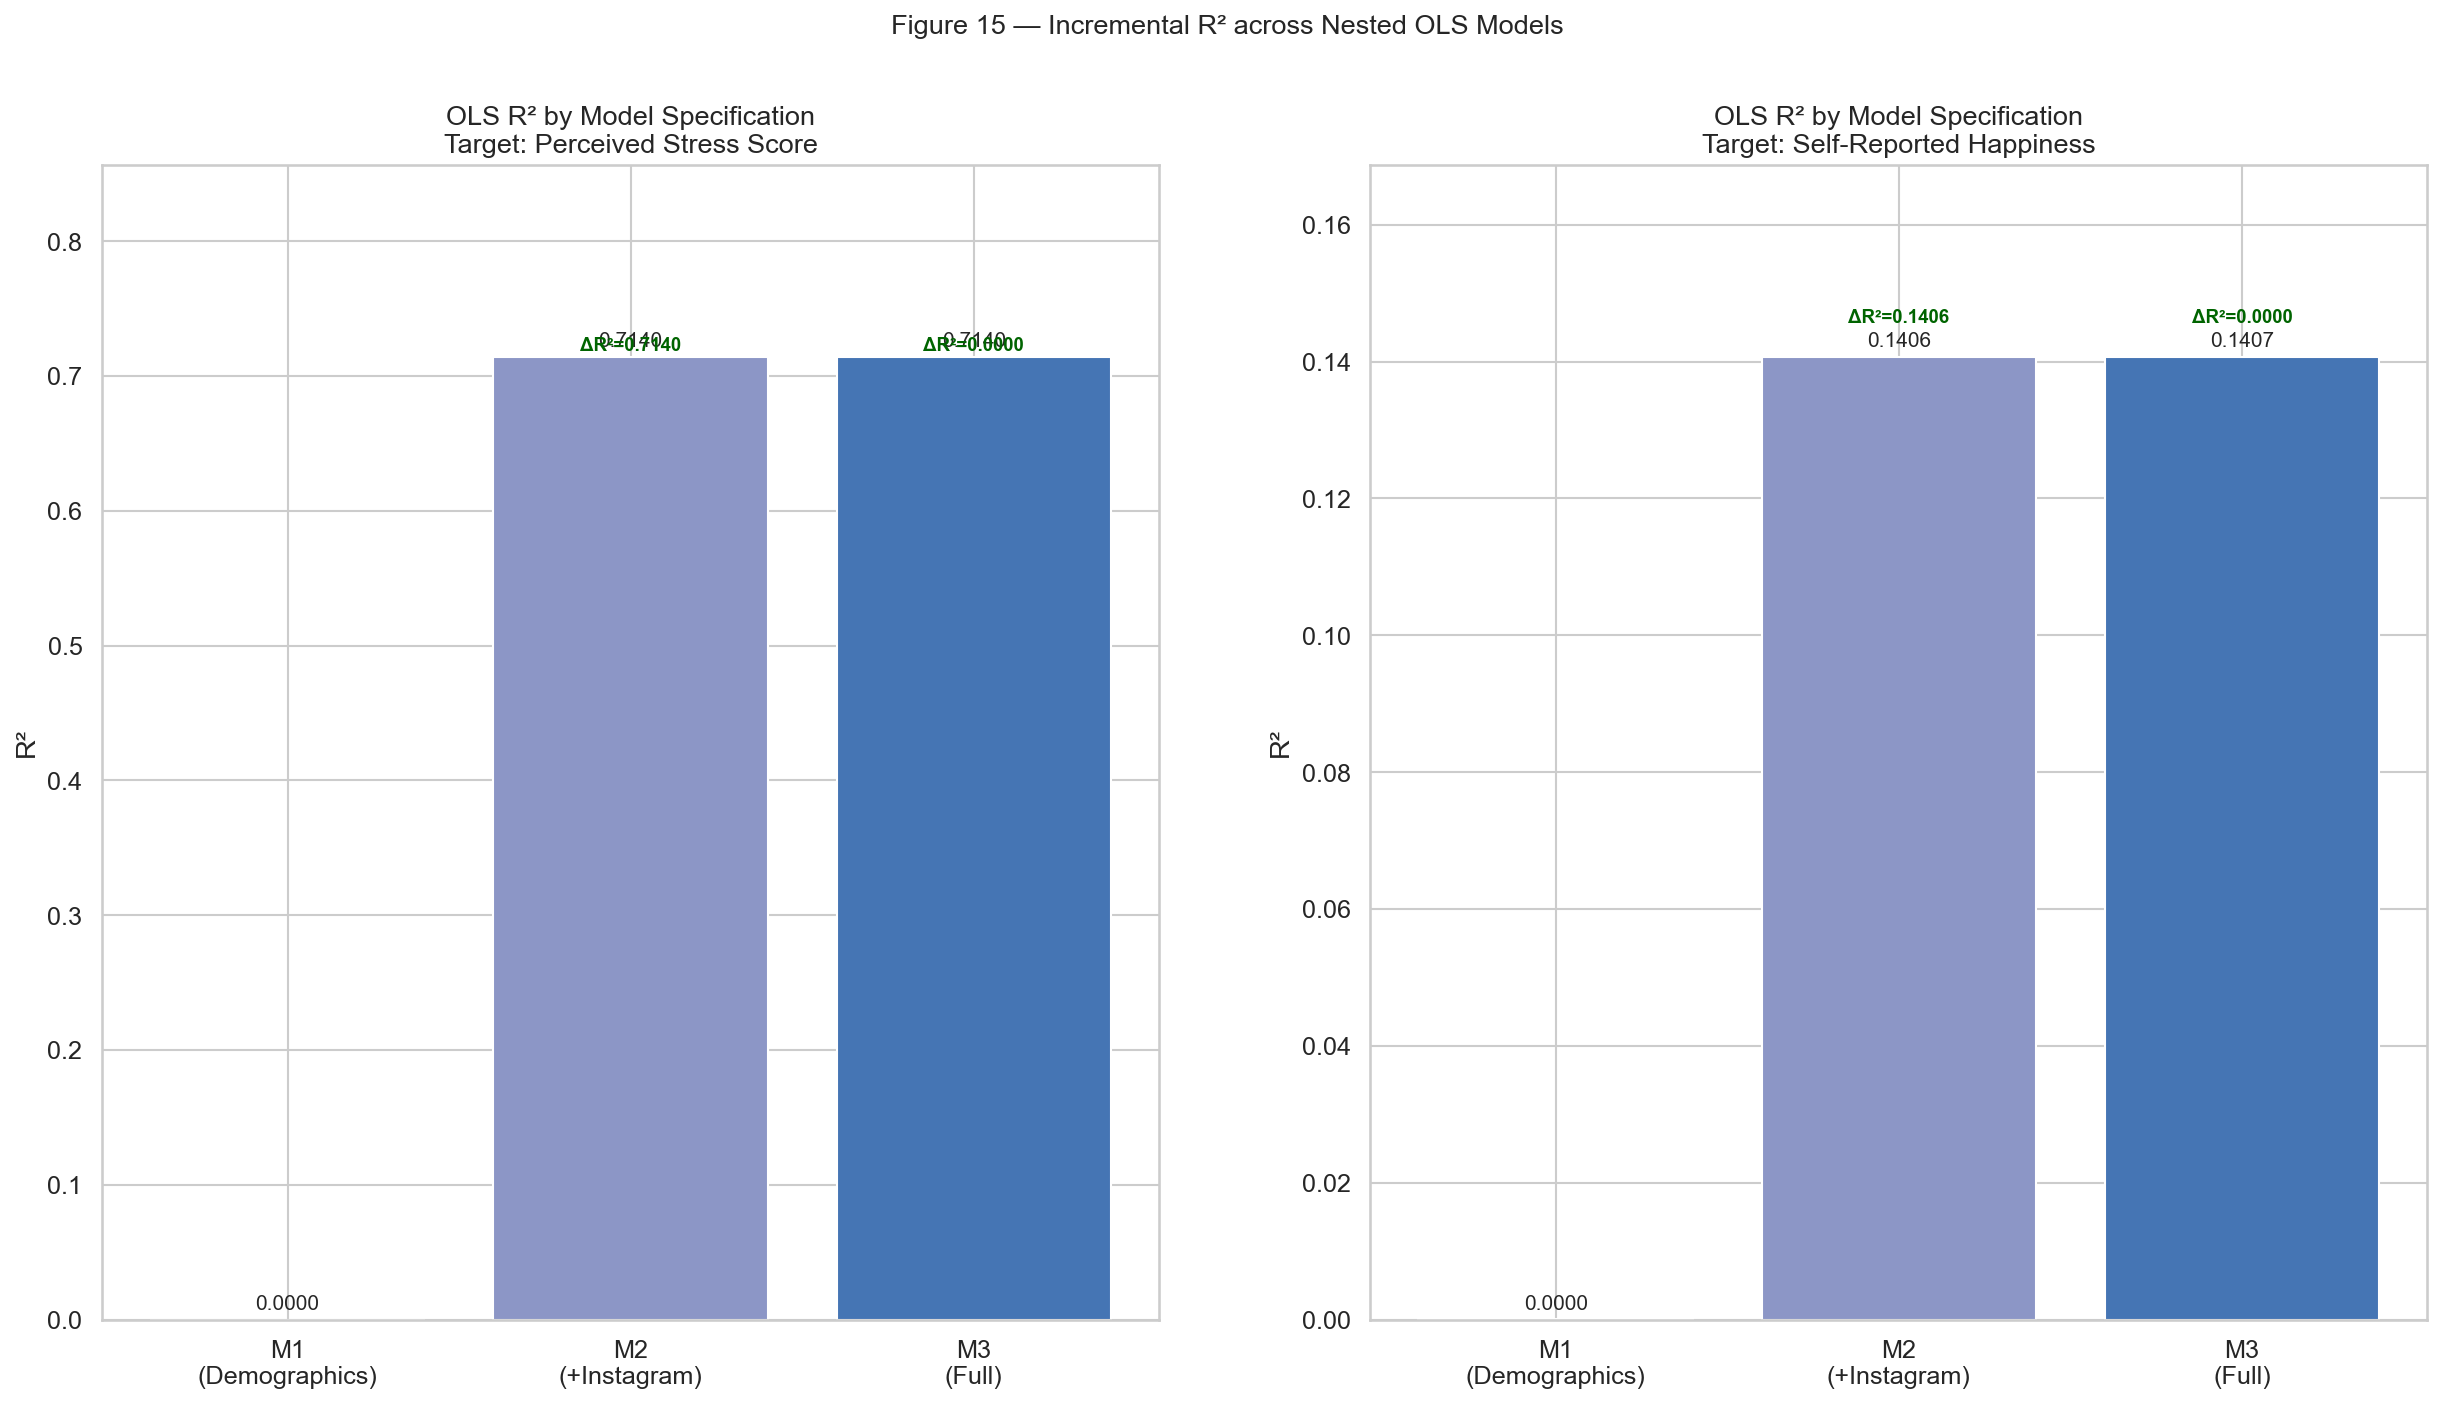

In [7]:
def run_ols_models(df_in, outcome, predictors_demo, predictors_ig,
                   predictors_lifestyle, label="outcome"):
    """Run 3 nested OLS models and return results dict."""
    results = {}
    clean = df_in[predictors_demo + predictors_ig + predictors_lifestyle + [outcome]].dropna()
    Y = clean[outcome]

    def fit_model(X_cols, name):
        X = sm.add_constant(clean[X_cols])
        mod = sm.OLS(Y, X).fit(cov_type="HC3")
        results[name] = mod
        print(f"\n      Model {name}: n={len(clean):,}, R²={mod.rsquared:.4f}, "
              f"adj-R²={mod.rsquared_adj:.4f}, F={mod.fvalue:.2f}")
        # Standardized betas
        X_std = (clean[X_cols] - clean[X_cols].mean()) / clean[X_cols].std()
        Y_std = (Y - Y.mean()) / Y.std()
        X_std = sm.add_constant(X_std)
        mod_std = sm.OLS(Y_std, X_std).fit(cov_type="HC3")
        std_betas = mod_std.params.drop("const").sort_values(key=abs, ascending=False)
        print(f"      Top standardized betas (|beta*| > 0.05):")
        for feat, val in std_betas[std_betas.abs() > 0.05].items():
            ci = mod_std.conf_int().loc[feat]
            print(f"        {feat:40s}  beta*={val:+.4f}  "
                  f"[{ci[0]:+.4f}, {ci[1]:+.4f}]")
        return mod, mod_std

    m1, m1s = fit_model(predictors_demo, "M1 (Demographics only)")
    m2, m2s = fit_model(predictors_demo + predictors_ig, "M2 (+Instagram)")
    m3, m3s = fit_model(predictors_demo + predictors_ig + predictors_lifestyle,
                        "M3 (Full model)")

    delta_r2_ig  = results["M2 (+Instagram)"].rsquared - results["M1 (Demographics only)"].rsquared
    delta_r2_lif = results["M3 (Full model)"].rsquared - results["M2 (+Instagram)"].rsquared
    print(f"\n      ΔR² from adding IG features:        {delta_r2_ig:.4f}")
    print(f"      ΔR² from adding lifestyle features: {delta_r2_lif:.4f}")

    return results, m1s, m2s, m3s

stress_models, s_m1, s_m2, s_m3 = run_ols_models(
    df_sample,
    "perceived_stress_score",
    DEMO_COVARIATES, IG_PREDICTORS, LIFESTYLE_PREDS,
    label="stress"
)

# Save full OLS table
full_model_stress = stress_models["M3 (Full model)"]
ols_summary = pd.DataFrame({
    "coef":   full_model_stress.params,
    "HC3_se": full_model_stress.bse,
    "t":      full_model_stress.tvalues,
    "p":      full_model_stress.pvalues,
    "ci_lo":  full_model_stress.conf_int()[0],
    "ci_hi":  full_model_stress.conf_int()[1],
})
ols_summary.round(5)

# ── Comparison figure: R² across nested models ──────────────────────────
print("\n[3] OLS for Self-Reported Happiness ...")
happy_models, h_m1, h_m2, h_m3 = run_ols_models(
    df_sample,
    "self_reported_happiness",
    DEMO_COVARIATES, IG_PREDICTORS, LIFESTYLE_PREDS,
    label="happiness"
)
full_model_happy = happy_models["M3 (Full model)"]

# R² comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, models_dict, tgt in zip(
    axes,
    [stress_models, happy_models],
    ["Perceived Stress Score", "Self-Reported Happiness"]
):
    model_names = ["M1\n(Demographics)", "M2\n(+Instagram)", "M3\n(Full)"]
    r2_vals = [m.rsquared for m in models_dict.values()]
    bars = ax.bar(model_names, r2_vals,
                  color=["#b3cde3", "#8c96c6", "#4575b4"], edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
    ax.set_ylim(0, max(r2_vals) * 1.2)
    ax.set_ylabel("R²")
    ax.set_title(f"OLS R² by Model Specification\nTarget: {tgt}")
    for i in range(1, len(r2_vals)):
        delta = r2_vals[i] - r2_vals[i-1]
        ax.annotate(f"ΔR²={delta:.4f}", xy=(i, r2_vals[i]),
                    xytext=(i, r2_vals[i] + 0.005),
                    ha="center", fontsize=9, color="darkgreen", fontweight="bold")

plt.suptitle("Figure 15 — Incremental R² across Nested OLS Models", fontsize=13)

Standardized coefficient plots (forest plots)

Text(0.5, 0.98, 'Figure 16 — Forest Plots: Standardized OLS Coefficients')

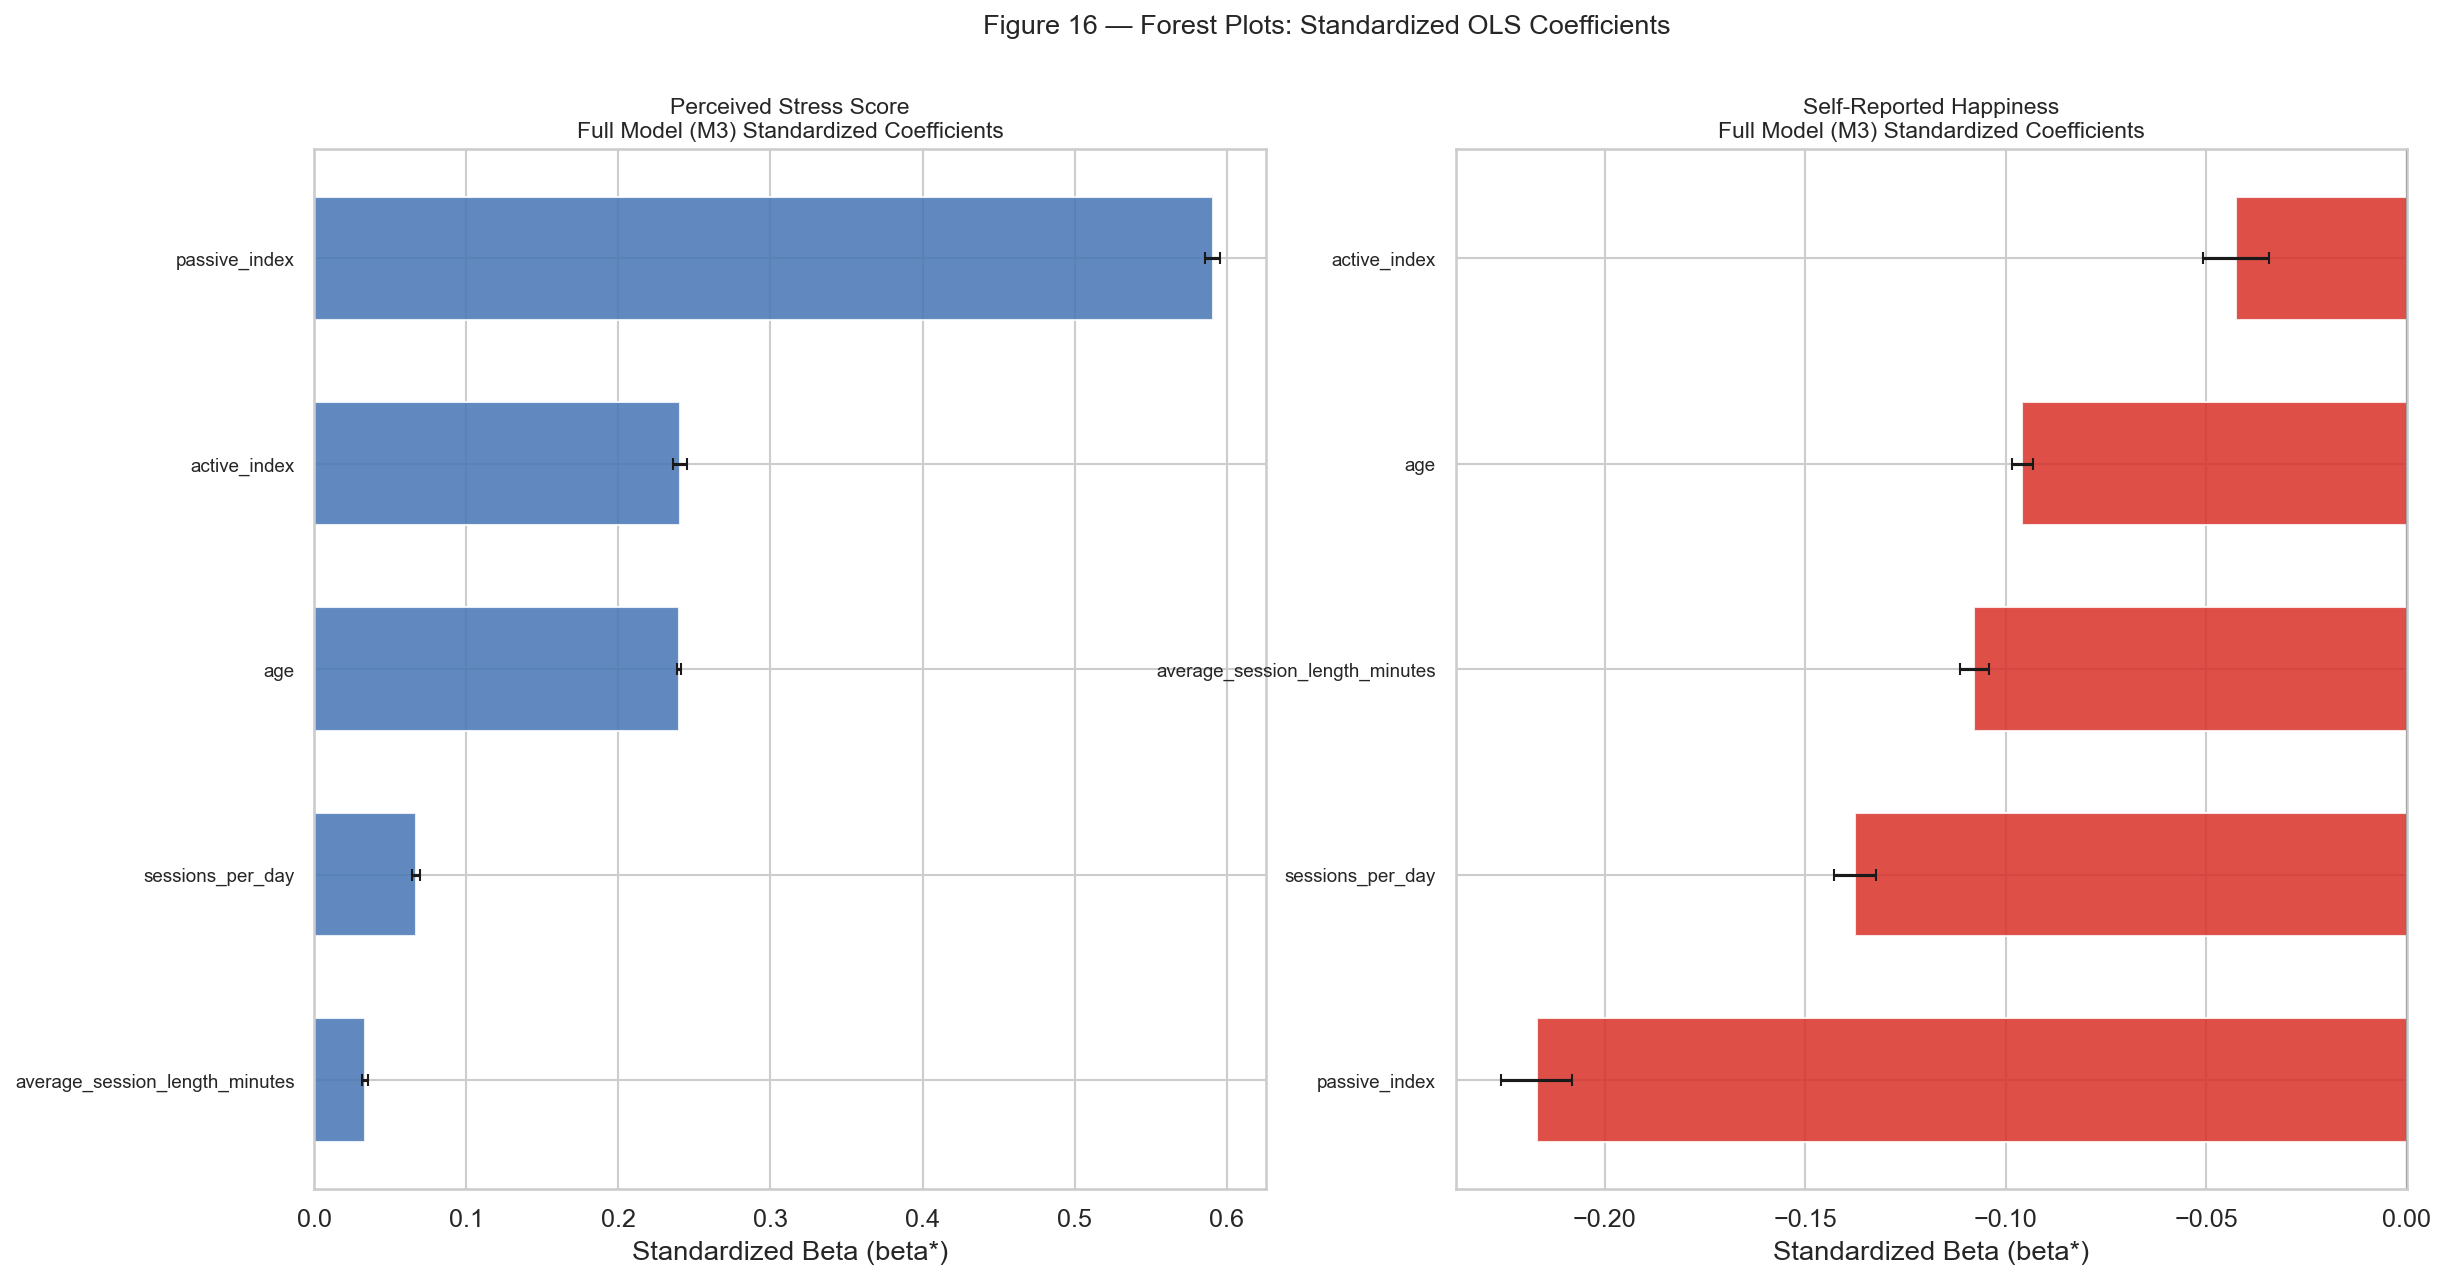

In [18]:
def forest_plot(mod_std, title, ax, threshold=0.03):
    coefs = mod_std.params.drop("const")
    ci    = mod_std.conf_int().drop("const")
    df_plot = pd.DataFrame({
        "feature": coefs.index,
        "beta":    coefs.values,
        "lo":      ci[0].values,
        "hi":      ci[1].values,
    }).sort_values("beta")
    df_plot = df_plot[df_plot["beta"].abs() > threshold]
    colors = ["#d73027" if v < 0 else "#4575b4" for v in df_plot["beta"]]
    y_pos  = range(len(df_plot))
    ax.barh(y_pos, df_plot["beta"], xerr=[
        df_plot["beta"] - df_plot["lo"],
        df_plot["hi"] - df_plot["beta"]
    ], color=colors, capsize=3, alpha=0.85, height=0.6)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(df_plot["feature"], fontsize=9)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Standardized Beta (beta*)")
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
forest_plot(s_m3, "Perceived Stress Score\nFull Model (M3) Standardized Coefficients",
            axes[0])
forest_plot(h_m3, "Self-Reported Happiness\nFull Model (M3) Standardized Coefficients",
            axes[1])
plt.suptitle("Figure 16 — Forest Plots: Standardized OLS Coefficients", fontsize=13)

Passive Vs Active Usage Differential Test


    perceived_stress_score:
      passive_index  beta* = +0.6370
      active_index   beta* = +0.2515
      Difference (passive - active) = +0.3854

    self_reported_happiness:
      passive_index  beta* = -0.3234
      active_index   beta* = -0.0618
      Difference (passive - active) = -0.2616


Text(0.5, 0.98, 'Figure 17 — Passive vs Active Instagram Use: Differential Association with Outcomes')

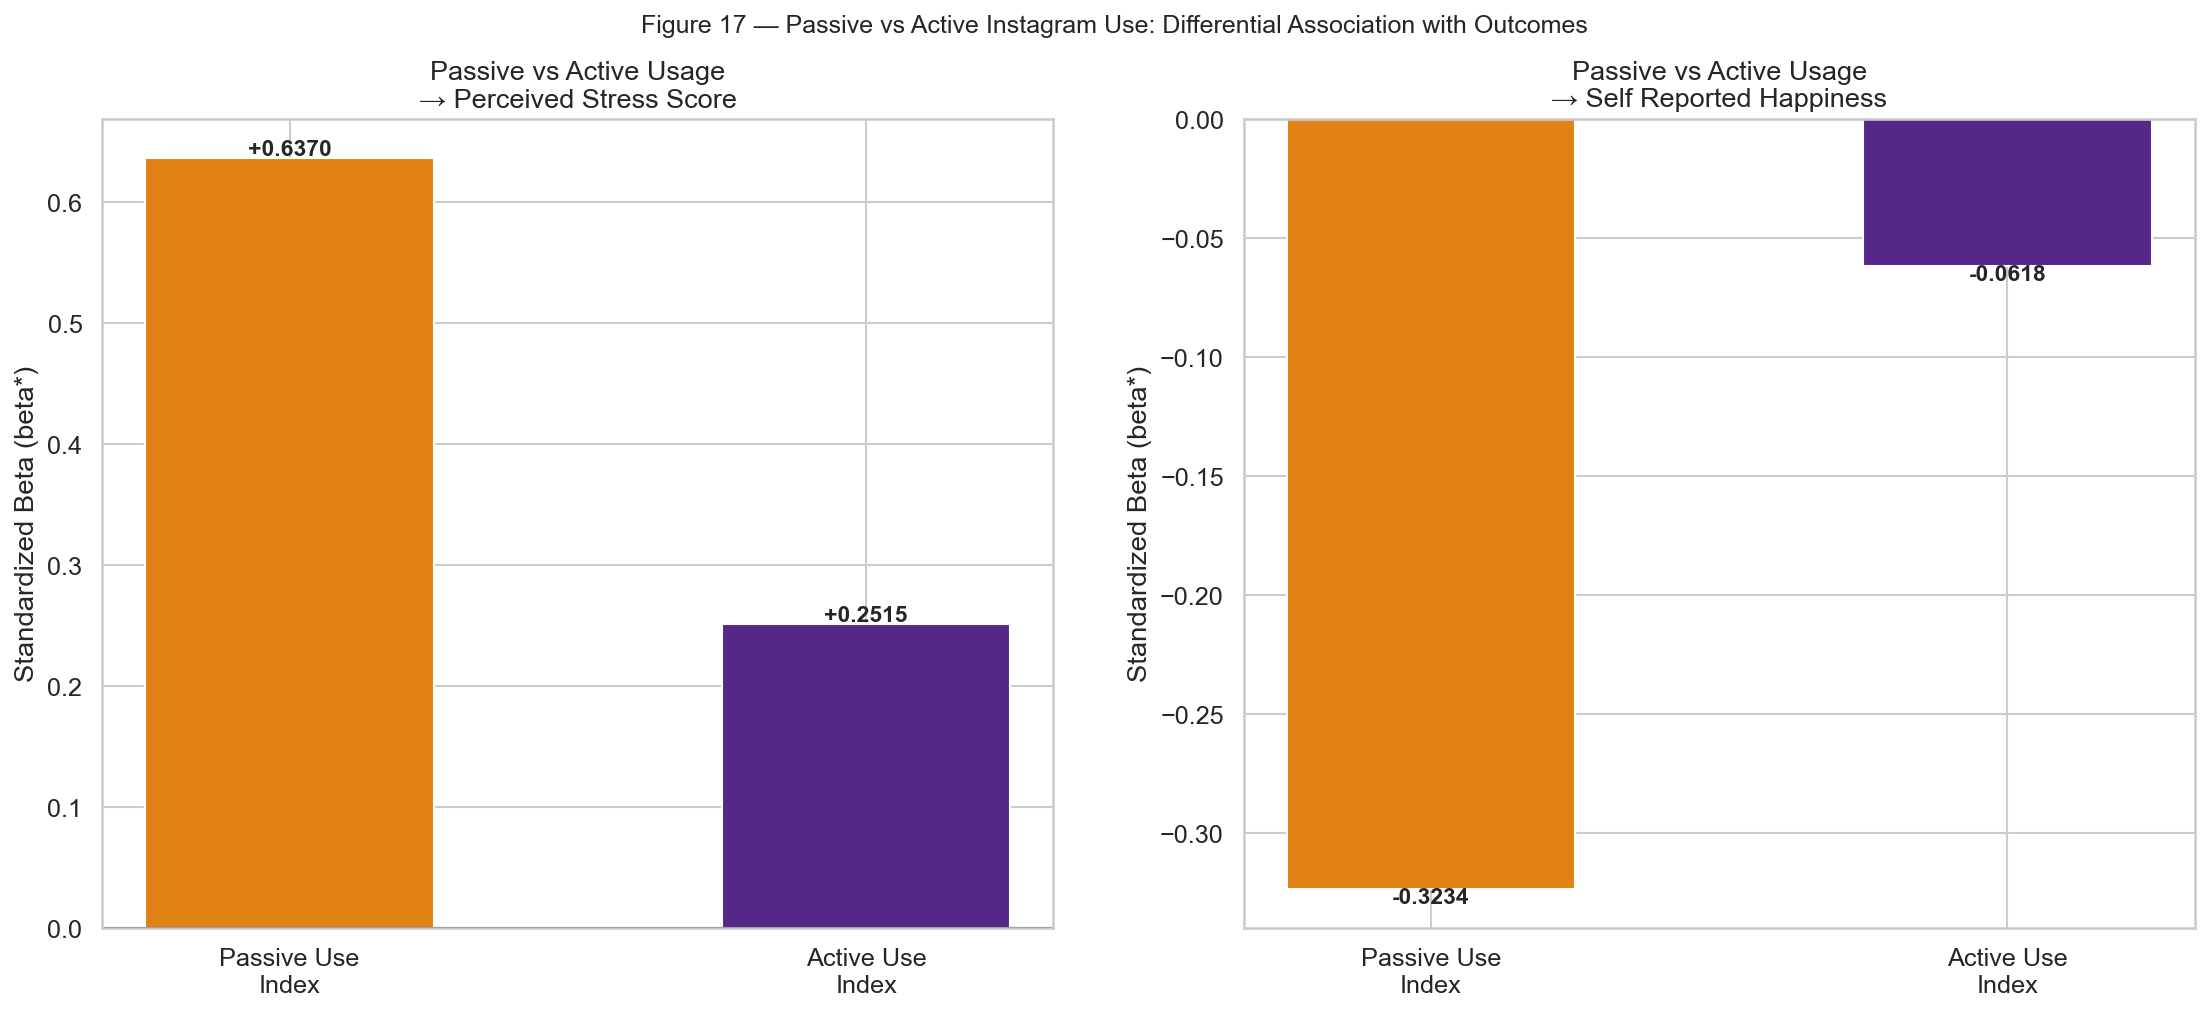

In [19]:
# Regress both on stress and happiness, compare standardized betas
results_passive_active = {}
for outcome in ["perceived_stress_score", "self_reported_happiness"]:
    clean = df_sample[["passive_index", "active_index"] + DEMO_COVARIATES + [outcome]].dropna()
    Y = clean[outcome]
    X_cols = ["passive_index", "active_index"] + DEMO_COVARIATES
    X = sm.add_constant(clean[X_cols])
    # Standardize
    X_std = (clean[X_cols] - clean[X_cols].mean()) / clean[X_cols].std()
    Y_std = (Y - Y.mean()) / Y.std()
    mod   = sm.OLS(Y_std, sm.add_constant(X_std)).fit(cov_type="HC3")
    b_pass = mod.params.get("passive_index", np.nan)
    b_act  = mod.params.get("active_index", np.nan)
    results_passive_active[outcome] = {
        "passive_beta*": b_pass, "active_beta*": b_act,
        "difference":    b_pass - b_act
    }
    print(f"\n    {outcome}:")
    print(f"      passive_index  beta* = {b_pass:+.4f}")
    print(f"      active_index   beta* = {b_act:+.4f}")
    print(f"      Difference (passive - active) = {b_pass - b_act:+.4f}")

pa_df = pd.DataFrame(results_passive_active).T
pa_df

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, outcome in zip(axes, ["perceived_stress_score", "self_reported_happiness"]):
    vals = [results_passive_active[outcome]["passive_beta*"],
            results_passive_active[outcome]["active_beta*"]]
    colors = ["#d73027" if v > 0 else "#4575b4" for v in vals]
    if outcome == "self_reported_happiness":
        colors = ["#d73027" if v > 0 else "#4575b4" for v in vals]
    ax.bar(["Passive Use\nIndex", "Active Use\nIndex"], vals,
           color=["#e08214", "#542788"], edgecolor="white", width=0.5)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylabel("Standardized Beta (beta*)")
    ax.set_title(f"Passive vs Active Usage\n→ {outcome.replace('_', ' ').title()}")
    for i, v in enumerate(vals):
        ax.text(i, v + (0.002 if v > 0 else -0.006), f"{v:+.4f}",
                ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Figure 17 — Passive vs Active Instagram Use: Differential Association with Outcomes",
             fontsize=12)

Poisson Regression
-- target: Daily Active minutes (treated as count-like int)

    GLM dataset: 500,000 rows, 22 predictors

    Fitting Poisson GLM ...
    Poisson dispersion statistic: 6.5605  (OVERDISPERSED)
                               IRR      lo95      hi95        p
const                     29.78897  29.70936  29.86879  0.00000
age                        1.00124   1.00122   1.00126  0.00000
female                     0.99945   0.99904   0.99986  0.00828
nonbinary                  1.00100   0.99979   1.00221  0.10372
urban                      1.00043   0.99984   1.00102  0.15045
suburban                   1.00017   0.99953   1.00081  0.60824
income_level_num           1.00013   0.99995   1.00032  0.16140
education_level_num        1.00049   1.00009   1.00088  0.01550
reels_watched_per_day      1.00112   1.00111   1.00112  0.00000
stories_viewed_per_day     1.00974   1.00972   1.00975  0.00000
time_on_feed_per_day       1.00104   1.00103   1.00105  0.00000
time_on_explore_per_day    1.00040   1.00038   1.00041  0.00000
ads_viewed_per_day         1.00160  

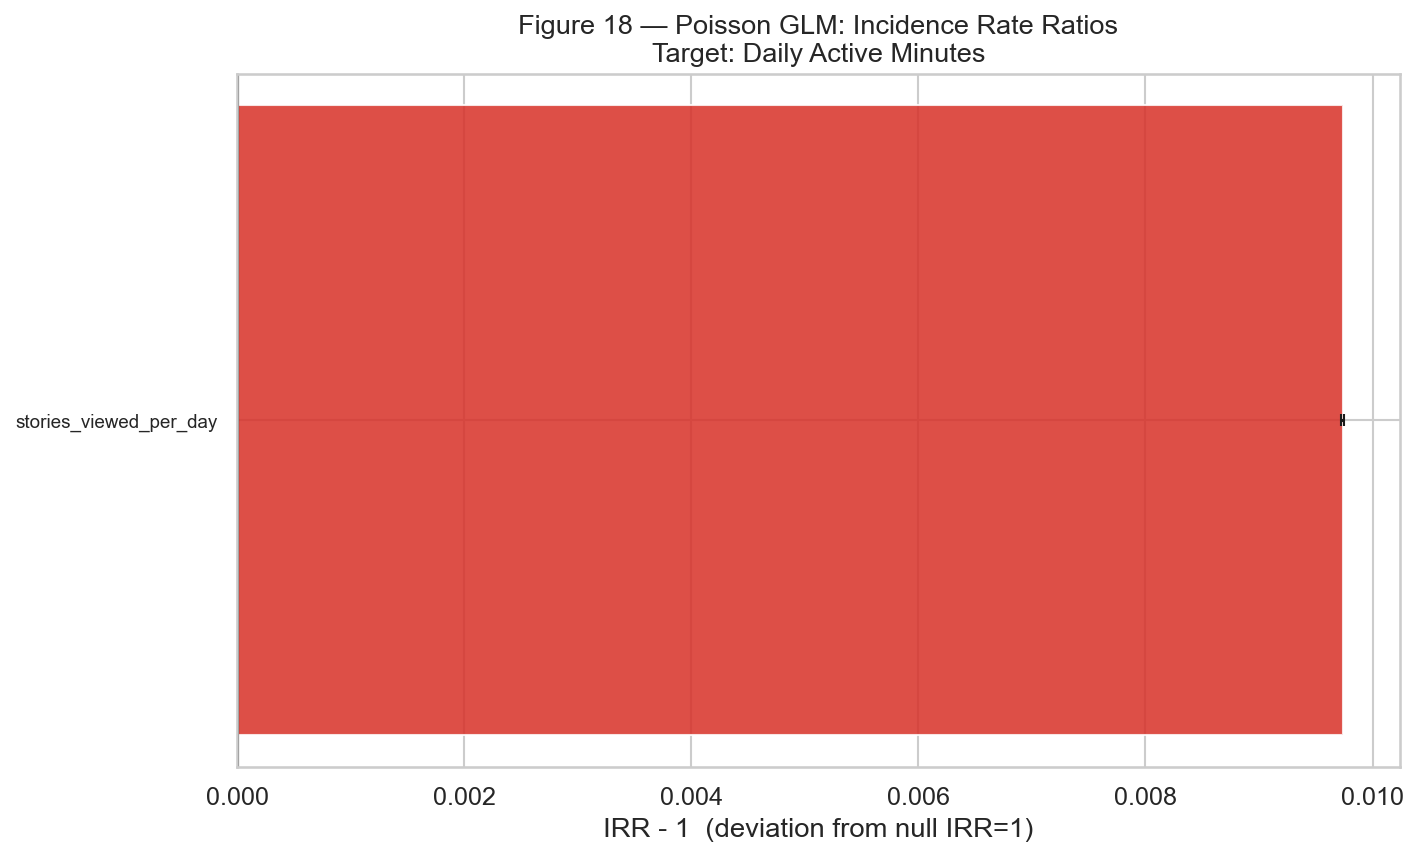

In [8]:
# Convert to integer for count model
df_sample["ig_minutes_int"] = df_sample["daily_active_minutes_instagram"].round(0).astype(int)

GLM_FEATURES = [c for c in DEMO_COVARIATES + IG_PREDICTORS + LIFESTYLE_PREDS
                if c != "passive_index" and c != "active_index"]

# Rebuild passive/active without including daily_active_minutes itself
IG_PASSIVE_V2 = [c for c in IG_PASSIVE if c != "daily_active_minutes_instagram"]
IG_ACTIVE_V2  = IG_ACTIVE

GLM_PREDS = [c for c in DEMO_COVARIATES + IG_PASSIVE_V2 + IG_ACTIVE_V2 + LIFESTYLE_PREDS
             if c in df_sample.columns]
GLM_PREDS = list(dict.fromkeys(GLM_PREDS))  # deduplicate

glm_data = df_sample[GLM_PREDS + ["ig_minutes_int"]].dropna()
print(f"    GLM dataset: {len(glm_data):,} rows, {len(GLM_PREDS)} predictors")

Y_glm = glm_data["ig_minutes_int"].clip(lower=1)
X_glm = sm.add_constant(glm_data[GLM_PREDS])

# Poisson
print("\n    Fitting Poisson GLM ...")
try:
    poisson_mod = sm.GLM(Y_glm, X_glm, family=sm.families.Poisson()).fit(maxiter=100)
    # Cameron-Trivedi dispersion test approximation
    fitted_pois = poisson_mod.fittedvalues
    pearson_resid = poisson_mod.resid_pearson
    n_obs = len(Y_glm)
    p_pred = len(GLM_PREDS) + 1
    dispersion = np.sum(pearson_resid**2) / (n_obs - p_pred)
    print(f"    Poisson dispersion statistic: {dispersion:.4f}  "
          f"({'OVERDISPERSED' if dispersion > 1.5 else 'approximately equidispersed'})")
    pois_irr = pd.DataFrame({
        "IRR":   np.exp(poisson_mod.params),
        "lo95":  np.exp(poisson_mod.conf_int()[0]),
        "hi95":  np.exp(poisson_mod.conf_int()[1]),
        "p":     poisson_mod.pvalues,
    }).round(5)
    print(pois_irr)
    print(f"    Poisson AIC: {poisson_mod.aic:.2f}")
    POISSON_OK = True
except Exception as e:
    print(f"    Poisson fitting error: {e}")
    POISSON_OK = False
    dispersion = 999

# Negative Binomial (if overdispersed)
print("\n    Fitting Negative Binomial GLM ...")
try:
    nb_mod = sm.GLM(Y_glm, X_glm,
                    family=sm.families.NegativeBinomial(alpha=dispersion if dispersion > 1 else 1.0)
                    ).fit(maxiter=200)
    nb_irr = pd.DataFrame({
        "IRR":   np.exp(nb_mod.params),
        "lo95":  np.exp(nb_mod.conf_int()[0]),
        "hi95":  np.exp(nb_mod.conf_int()[1]),
        "p":     nb_mod.pvalues,
    }).round(5)
    print(nb_irr)
    print(f"    NB AIC: {nb_mod.aic:.2f}")
    NB_OK = True
except Exception as e:
    print(f"    NB fitting issue: {e}. Continuing with Poisson only.")
    NB_OK = False

if POISSON_OK:
    irr_plot = pois_irr.drop("const").copy()
    irr_plot = irr_plot[(irr_plot["IRR"] - 1).abs() > 0.005]
    irr_plot = irr_plot.sort_values("IRR")
    fig, ax = plt.subplots(figsize=(10, max(6, len(irr_plot)*0.45)))
    y_pos = range(len(irr_plot))
    colors = ["#d73027" if v > 1 else "#4575b4" for v in irr_plot["IRR"]]
    ax.barh(list(y_pos), irr_plot["IRR"] - 1,
            xerr=[irr_plot["IRR"] - irr_plot["lo95"],
                  irr_plot["hi95"] - irr_plot["IRR"]],
            color=colors, capsize=3, alpha=0.85)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(irr_plot.index, fontsize=9)
    ax.axvline(0, color="black", linewidth=1.5)
    ax.set_xlabel("IRR - 1  (deviation from null IRR=1)")
    ax.set_title("Figure 18 — Poisson GLM: Incidence Rate Ratios\nTarget: Daily Active Minutes")


Ordered Logitic Regression... Self reported happiness

    OL sample: 100,000 rows

    Ordered Logit — Log-Likelihood: -222662.54
    Pseudo R² (McFadden): 0.0330
                                    coef        se          z              p  \
age                            -0.011217  0.000381 -29.459020  9.649168e-191   
female                          0.019261  0.011209   1.718415   8.572096e-02   
nonbinary                      -0.053340  0.033553  -1.589738   1.118940e-01   
urban                          -0.026563  0.016076  -1.652370   9.845917e-02   
suburban                       -0.019498  0.017455  -1.117089   2.639564e-01   
income_level_num               -0.004181  0.005134  -0.814387   4.154232e-01   
education_level_num             0.016388  0.010846   1.511022   1.307828e-01   
passive_index                  -0.392120  0.020623 -19.013682   1.313970e-80   
active_index                   -0.119783  0.020115  -5.954925   2.601908e-09   
sessions_per_day               -0.033303  0.001523 -21.866568  5.407551e-106   
average_ses

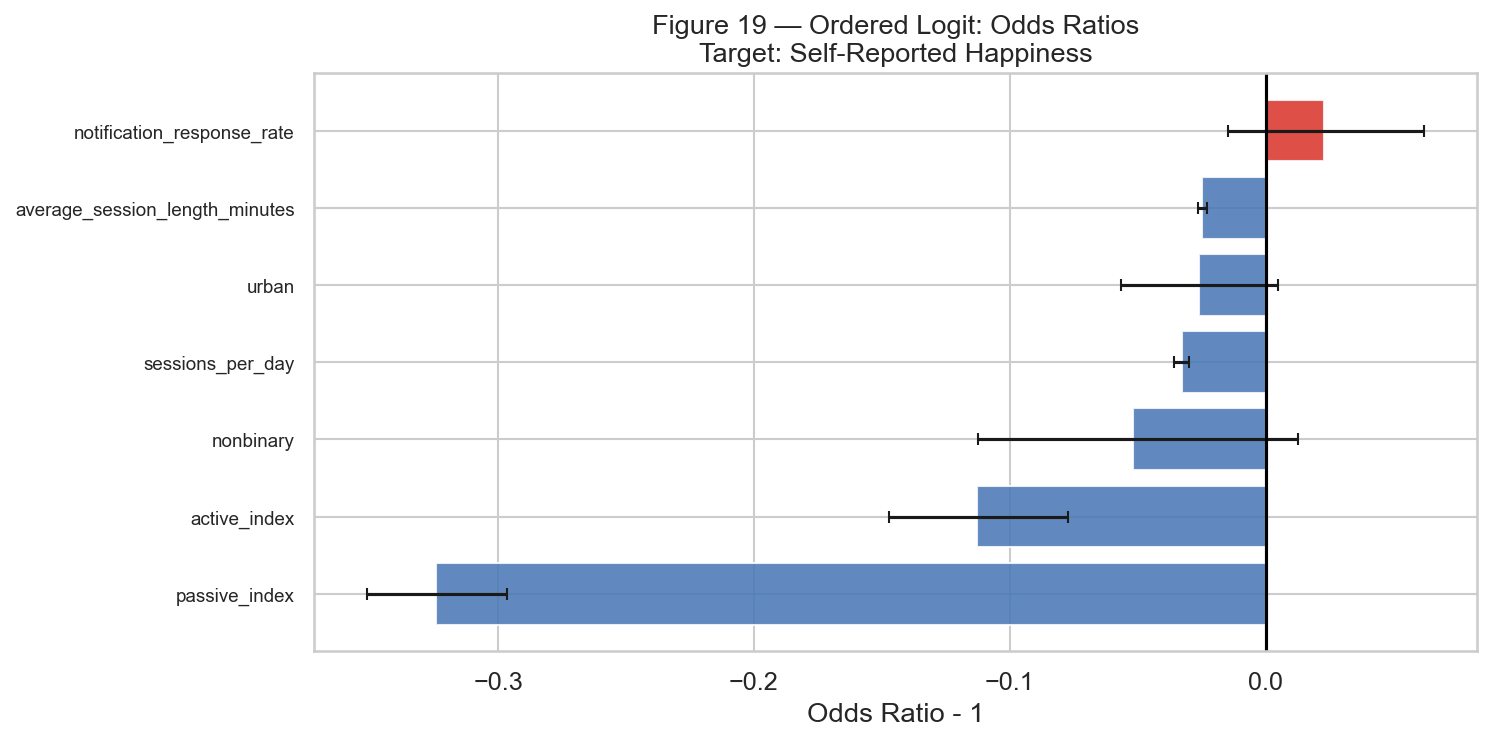

In [9]:
# Convert happiness to integer 1-10
df_sample["happiness_int"] = df_sample["self_reported_happiness"].round(0).astype(int).clip(1, 10)

OL_PREDS = [c for c in DEMO_COVARIATES + IG_PREDICTORS + LIFESTYLE_PREDS
            if c in df_sample.columns]

ol_data = df_sample[OL_PREDS + ["happiness_int"]].dropna()
# Subsample for speed (ordered model is slow at 500k)
ol_sub  = ol_data.sample(min(100_000, len(ol_data)), random_state=42)
print(f"    OL sample: {len(ol_sub):,} rows")

X_ol = ol_sub[OL_PREDS]
Y_ol = ol_sub["happiness_int"]

try:
    ol_mod = OrderedModel(Y_ol, X_ol, distr="logit")
    ol_res = ol_mod.fit(method="bfgs", maxiter=500, disp=False)
    print(f"\n    Ordered Logit — Log-Likelihood: {ol_res.llf:.2f}")
    print(f"    Pseudo R² (McFadden): {1 - ol_res.llf / ol_res.llnull:.4f}")

    # Coefficients table
    ol_table = pd.DataFrame({
        "coef":  ol_res.params,
        "se":    ol_res.bse,
        "z":     ol_res.tvalues,
        "p":     ol_res.pvalues,
        "lo95":  ol_res.conf_int()[0],
        "hi95":  ol_res.conf_int()[1],
    })
    print(ol_table)
    # Odds ratios (exp of coefficients for predictors only)
    coef_preds = ol_res.params[:len(OL_PREDS)]
    ci_preds   = ol_res.conf_int().iloc[:len(OL_PREDS)]
    or_df = pd.DataFrame({
        "OR":    np.exp(coef_preds),
        "lo95":  np.exp(ci_preds[0]),
        "hi95":  np.exp(ci_preds[1]),
    }).sort_values("OR")

    top_or = or_df[(or_df["OR"] - 1).abs() > 0.02].copy()
    if len(top_or) > 0:
        fig, ax = plt.subplots(figsize=(10, max(5, len(top_or)*0.45)))
        y_pos = range(len(top_or))
        colors = ["#d73027" if v > 1 else "#4575b4" for v in top_or["OR"]]
        ax.barh(list(y_pos), top_or["OR"] - 1,
                xerr=[top_or["OR"] - top_or["lo95"],
                      top_or["hi95"] - top_or["OR"]],
                color=colors, capsize=3, alpha=0.85)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(top_or.index, fontsize=9)
        ax.axvline(0, color="black", linewidth=1.5)
        ax.set_xlabel("Odds Ratio - 1")
        ax.set_title("Figure 19 — Ordered Logit: Odds Ratios\nTarget: Self-Reported Happiness")

    OL_OK = True
except Exception as e:
    print(f"    Ordered logit issue: {e}")
    OL_OK = False


Interaction Analysiss


    passive_use × income_level → stress:
      beta_interaction = -0.00056  [-0.01547, +0.01435]  p=9.4115e-01
      ΔR² from interaction term: 0.000000

    passive_use × age → stress:
      beta_interaction = +0.00431  [+0.00324, +0.00539]  p=4.1174e-15
      ΔR² from interaction term: 0.000026

    passive_use × sleep → stress:
      beta_interaction = -0.00093  [-0.01556, +0.01371]  p=9.0127e-01
      ΔR² from interaction term: 0.000000

    passive_use × exercise → happiness:
      beta_interaction = -0.00045  [-0.00225, +0.00135]  p=6.2194e-01
      ΔR² from interaction term: 0.000000
                      interaction      beta             p
0       passive × income → stress -0.000561  9.411531e-01
1          passive × age → stress  0.004312  4.117355e-15
2        passive × sleep → stress -0.000926  9.012730e-01
3  passive × exercise → happiness -0.000453  6.219392e-01


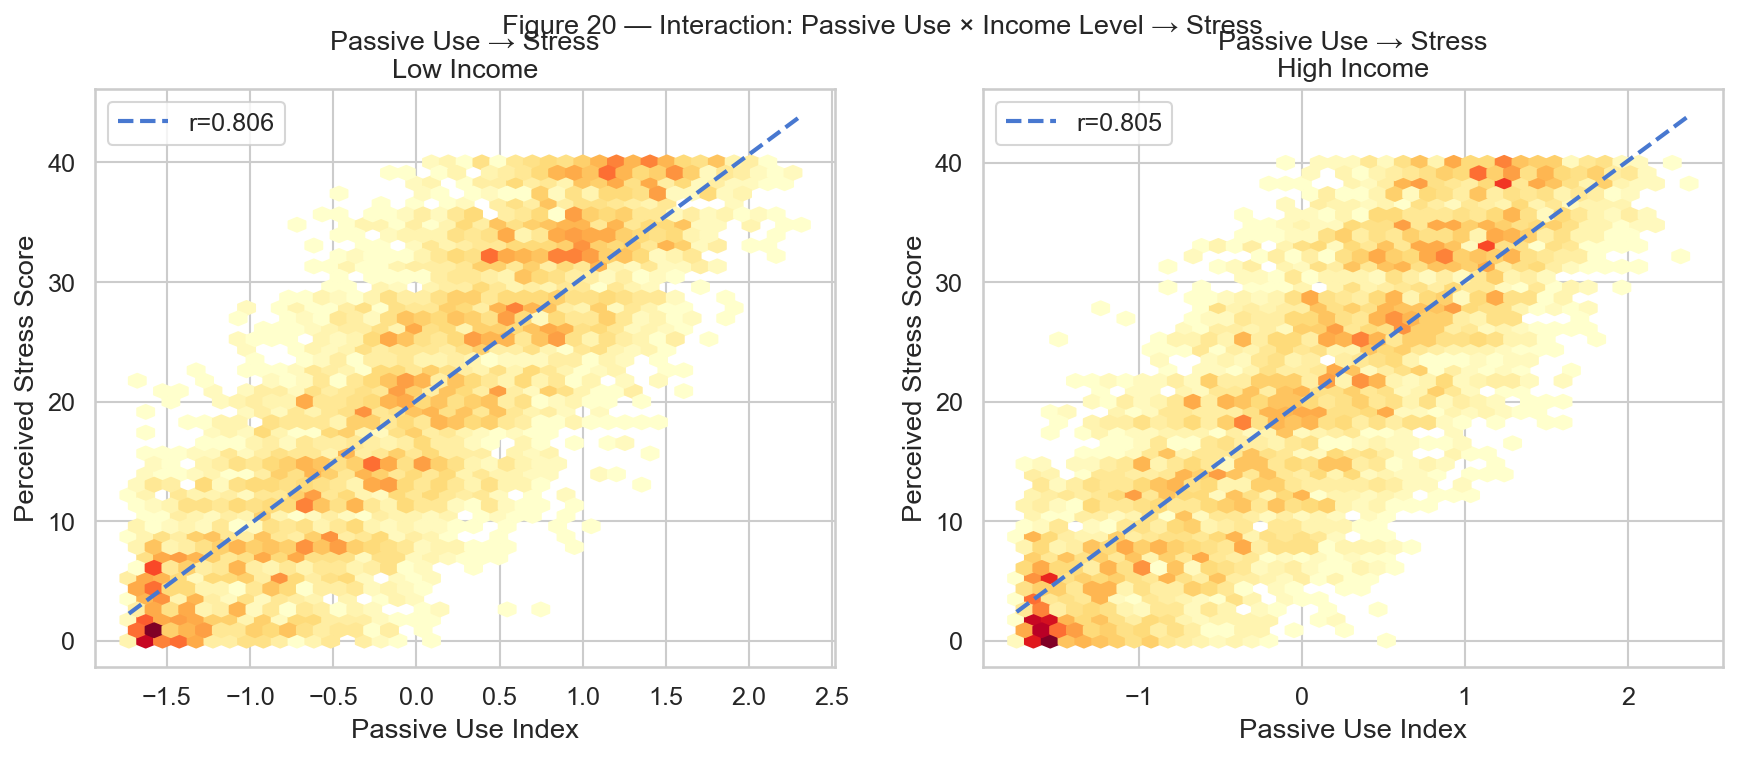

In [10]:
def run_interaction_ols(df_in, outcome, main_var, moderator, covariates,
                        label="interaction"):
    """Test moderation: outcome ~ main_var * moderator + covariates"""
    # Remove main_var and moderator from covariates to prevent duplicates
    covariates = [c for c in dict.fromkeys(covariates)  # deduplicate
                  if c != main_var and c != moderator]
    cols_needed = list(dict.fromkeys([main_var, moderator] + covariates + [outcome]))
    clean = df_in[cols_needed].dropna()

    # Center predictors for interpretable interaction terms
    X = clean[[main_var, moderator] + covariates].copy()
    X[main_var]   = X[main_var] - X[main_var].mean()
    X[moderator]  = X[moderator] - X[moderator].mean()
    X["interact"] = X[main_var] * X[moderator]

    Y = clean[outcome]
    mod = sm.OLS(Y, sm.add_constant(X)).fit(cov_type="HC3")
    b_int  = mod.params.get("interact", np.nan)
    p_int  = mod.pvalues.get("interact", np.nan)
    ci_int = mod.conf_int().loc["interact"] if "interact" in mod.conf_int().index else [np.nan, np.nan]

    print(f"\n    {label}:")
    print(f"      beta_interaction = {b_int:+.5f}  "
          f"[{ci_int[0]:+.5f}, {ci_int[1]:+.5f}]  p={p_int:.4e}")

    # R² change from interaction term
    X_no_int = X.drop("interact", axis=1)
    mod_no_int = sm.OLS(Y, sm.add_constant(X_no_int)).fit(cov_type="HC3")
    delta_r2 = mod.rsquared - mod_no_int.rsquared
    print(f"      ΔR² from interaction term: {delta_r2:.6f}")
    return mod, b_int, p_int

# Interaction 1: passive_index × income on stress
int1, b1, p1 = run_interaction_ols(
    df_sample, "perceived_stress_score",
    "passive_index", "income_level_num",
    [c for c in DEMO_COVARIATES if c not in ["income_level_num"]] + LIFESTYLE_PREDS,
    "passive_use × income_level → stress"
)

# Interaction 2: passive_index × age on stress
int2, b2, p2 = run_interaction_ols(
    df_sample, "perceived_stress_score",
    "passive_index", "age",
    [c for c in DEMO_COVARIATES if c != "age"] + LIFESTYLE_PREDS,
    "passive_use × age → stress"
)

# Interaction 3: passive_index × sleep on stress
int3, b3, p3 = run_interaction_ols(
    df_sample, "perceived_stress_score",
    "passive_index", "sleep_hours_per_night",
    DEMO_COVARIATES,
    "passive_use × sleep → stress"
)

# Interaction 4: passive × exercise on happiness
int4, b4, p4 = run_interaction_ols(
    df_sample, "self_reported_happiness",
    "passive_index", "exercise_hours_per_week",
    DEMO_COVARIATES + LIFESTYLE_PREDS,
    "passive_use × exercise → happiness"
)

# Save interaction results
int_results = pd.DataFrame([
    {"interaction": "passive × income → stress",    "beta": b1, "p": p1},
    {"interaction": "passive × age → stress",       "beta": b2, "p": p2},
    {"interaction": "passive × sleep → stress",     "beta": b3, "p": p3},
    {"interaction": "passive × exercise → happiness","beta": b4, "p": p4},
])
print(int_results)
# Visualization: Interaction plot (passive × income → stress)
if "income_level_num" in df_sample.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (income_val, label_str) in zip(axes, [(1, "Low Income"), (5, "High Income")]):
        sub = df_sample[df_sample["income_level_num"] == income_val]
        if len(sub) > 1000:
            sub = sub.sample(5000, random_state=42)
        x = sub["passive_index"].dropna()
        y = sub["perceived_stress_score"].loc[x.index]
        valid = x.notna() & y.notna()
        x, y = x[valid], y[valid]
        ax.hexbin(x, y, gridsize=40, cmap="YlOrRd", mincnt=1)
        m, b, r, p, _ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, m*xr+b, "b--", linewidth=2, label=f"r={r:.3f}")
        ax.set_xlabel("Passive Use Index")
        ax.set_ylabel("Perceived Stress Score")
        ax.set_title(f"Passive Use → Stress\n{label_str}")
        ax.legend()

    plt.suptitle("Figure 20 — Interaction: Passive Use × Income Level → Stress",
                 fontsize=13)

Text(0.5, 0.98, 'Figure 22 — OLS Regression Diagnostics (Perceived Stress ~ Full Model)')

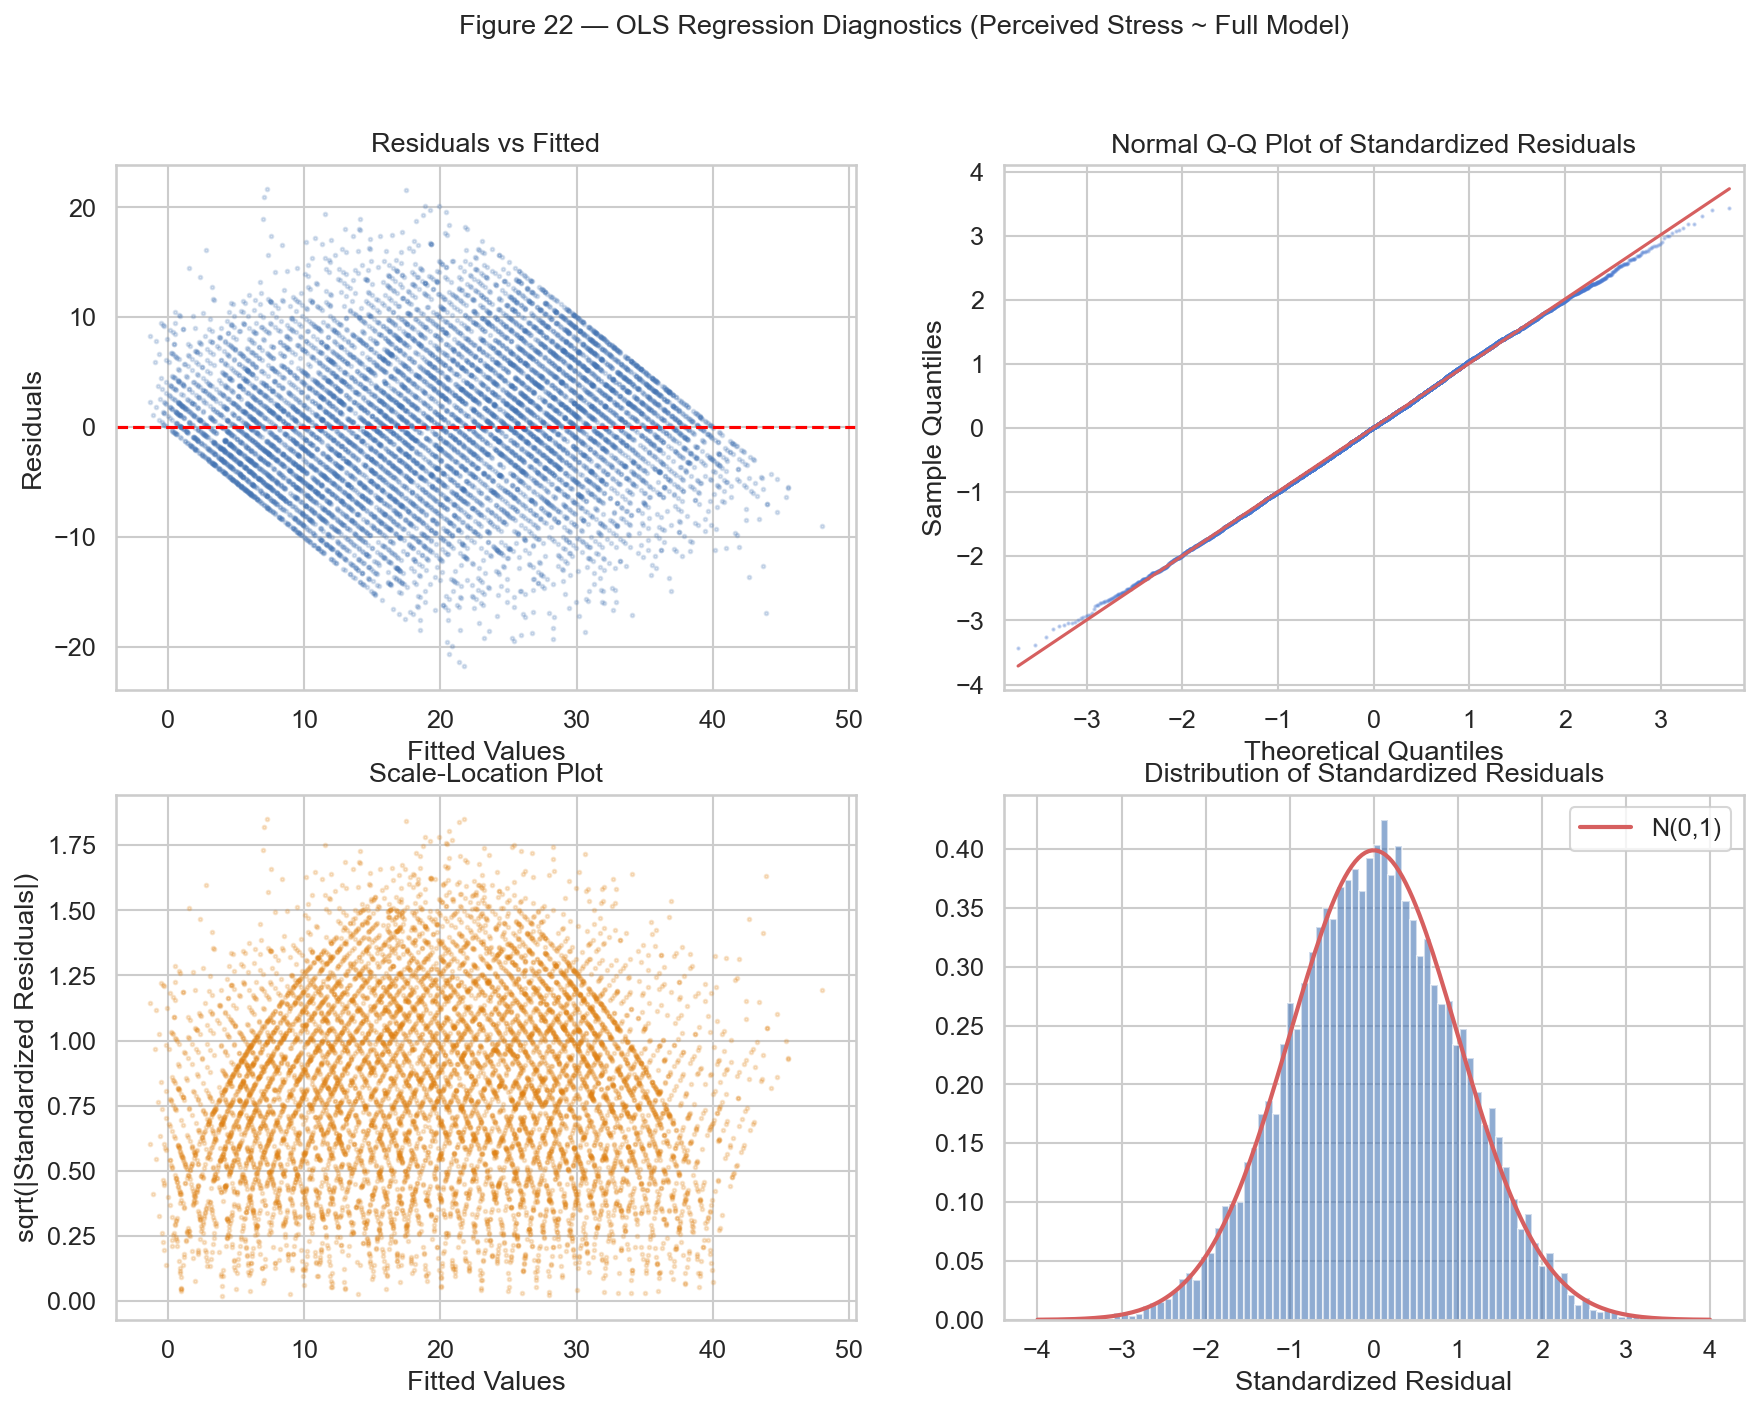

In [11]:
fitted = full_model_stress.fittedvalues
residuals = full_model_stress.resid
std_resid  = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
ax = axes[0, 0]
sample_diag = np.random.choice(len(fitted), min(10000, len(fitted)), replace=False)
ax.scatter(fitted.iloc[sample_diag], residuals.iloc[sample_diag],
           alpha=0.2, s=3, color="#4575b4")
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")

# Q-Q plot of residuals
ax = axes[0, 1]
from statsmodels.graphics.gofplots import qqplot
qqplot(std_resid.iloc[sample_diag], line="s", ax=ax, markersize=1, alpha=0.3)
ax.set_title("Normal Q-Q Plot of Standardized Residuals")

# Scale-Location
ax = axes[1, 0]
ax.scatter(fitted.iloc[sample_diag], np.sqrt(np.abs(std_resid.iloc[sample_diag])),
           alpha=0.2, s=3, color="#e08214")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("sqrt(|Standardized Residuals|)")
ax.set_title("Scale-Location Plot")

# Residual distribution
ax = axes[1, 1]
ax.hist(std_resid.iloc[sample_diag], bins=80, density=True,
        color="#4575b4", alpha=0.6, edgecolor="white")
xr = np.linspace(-4, 4, 200)
ax.plot(xr, stats.norm.pdf(xr), "r-", linewidth=2, label="N(0,1)")
ax.set_xlabel("Standardized Residual")
ax.set_title("Distribution of Standardized Residuals")
ax.legend()

plt.suptitle("Figure 22 — OLS Regression Diagnostics (Perceived Stress ~ Full Model)",
             fontsize=13)

In [24]:
print(f"""
Key Findings:
1. OLS Nested Models (Stress):
   M1 (Demo only)   R² = {stress_models['M1 (Demographics only)'].rsquared:.4f}
   M2 (+Instagram)  R² = {stress_models['M2 (+Instagram)'].rsquared:.4f}
   M3 (Full)        R² = {stress_models['M3 (Full model)'].rsquared:.4f}

2. Passive vs Active Instagram Use:
   passive_index beta* (stress)    = {results_passive_active['perceived_stress_score']['passive_beta*']:+.4f}
   active_index  beta* (stress)    = {results_passive_active['perceived_stress_score']['active_beta*']:+.4f}
   passive_index beta* (happiness) = {results_passive_active['self_reported_happiness']['passive_beta*']:+.4f}
   active_index  beta* (happiness) = {results_passive_active['self_reported_happiness']['active_beta*']:+.4f}
""")


Key Findings:
1. OLS Nested Models (Stress):
   M1 (Demo only)   R² = 0.0000
   M2 (+Instagram)  R² = 0.7140
   M3 (Full)        R² = 0.7140

2. Passive vs Active Instagram Use:
   passive_index beta* (stress)    = +0.6370
   active_index  beta* (stress)    = +0.2515
   passive_index beta* (happiness) = -0.3234
   active_index  beta* (happiness) = -0.0618

